# Plot Customisation

In [1]:
# Import libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_beginner_course/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

Customising the line graph from 12_exercise

<Axes: xlabel='job_posted_month'>

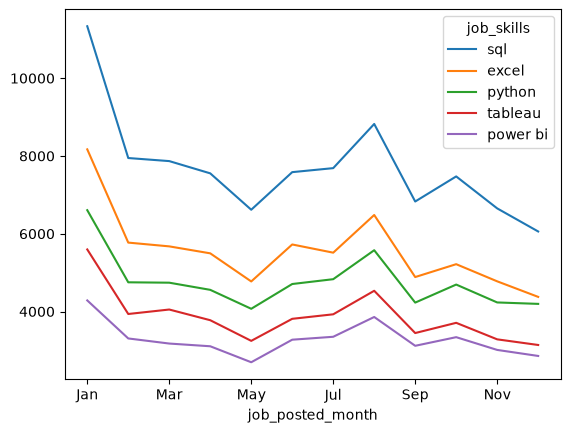

In [8]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_DA_explode = df_DA.explode('job_skills')

df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_pivot.loc['total'] = df_DA_pivot.sum()
df_DA_pivot.loc['total'].sort_values(ascending =False)
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['total'].sort_values(ascending =False).index]
df_DA_pivot = df_DA_pivot.drop('total')

df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

df_DA_pivot.iloc[:,:5].plot(kind='line')

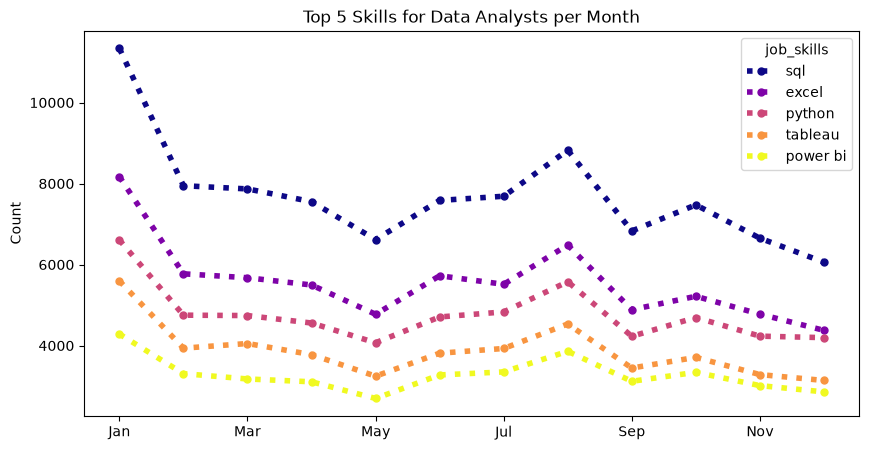

In [20]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':' , # options: '-', '--', '-.', ':'
    colormap='plasma' , # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis' 
    markersize=5,
    marker='o',  # options: 'o', 'x', '+', '*', 's', ',', '.', '1', '2', '3', '4', ...
    figsize=(10, 5)
)
plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

Customising the scatter plot from 15_matplotlib_scatter_plot

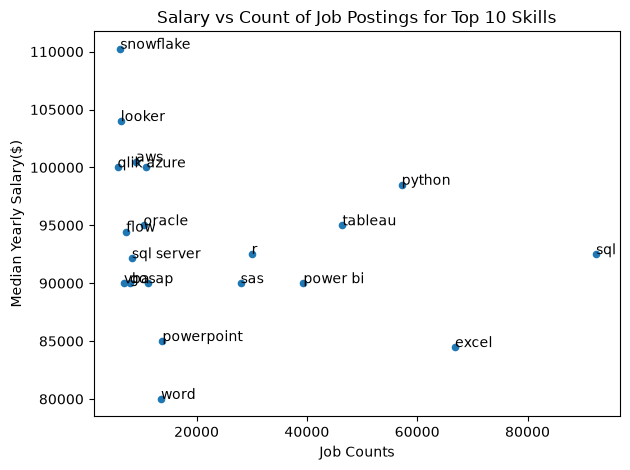

In [23]:
df_explode = df_DA.explode('job_skills')
skills_stats = df_explode.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)
skills_stats = skills_stats.sort_values(by='skill_count', ascending=False).head(20)

skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.title('Salary vs Count of Job Postings for Top 10 Skills')
plt.ylabel('Median Yearly Salary($)')
plt.xlabel('Job Counts')

for i, skill in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], skill)


plt.tight_layout()

In [24]:
pip install adjustText


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 46.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [adjustText]
Note: you may need to restart the kernel to use updated packages.


In [25]:
from adjustText import adjust_text

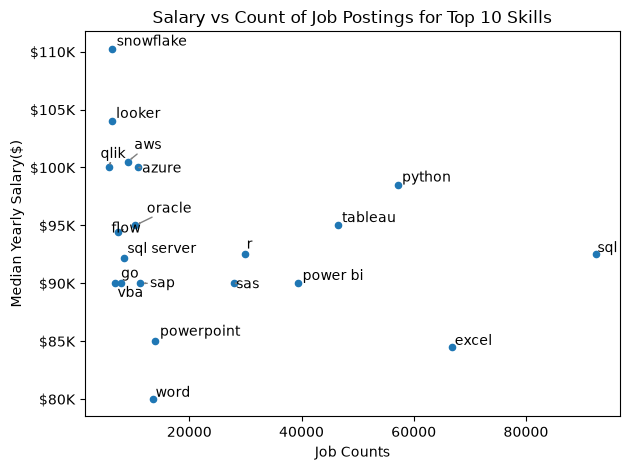

In [31]:

skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')

texts=[]
for i, skill in enumerate(skills_stats.index):
    texts.append(plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], skill))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

plt.title('Salary vs Count of Job Postings for Top 10 Skills')
plt.ylabel('Median Yearly Salary($)')
plt.xlabel('Job Counts')


plt.tight_layout()